   Unnamed: 0       image_id  \
0           0  Tumor- (1044)   
1           1    Tumor- (83)   
2           2   Tumor- (580)   
3           3  Tumor- (1701)   
4           4  Tumor- (1220)   

                                                path   diag  target  Class  
0  /content/data/CT KIDNEY DATASET Normal, CYST, ...  Tumor       3  Tumor  
1  /content/data/CT KIDNEY DATASET Normal, CYST, ...  Tumor       3  Tumor  
2  /content/data/CT KIDNEY DATASET Normal, CYST, ...  Tumor       3  Tumor  
3  /content/data/CT KIDNEY DATASET Normal, CYST, ...  Tumor       3  Tumor  
4  /content/data/CT KIDNEY DATASET Normal, CYST, ...  Tumor       3  Tumor  
(12446, 6)
Unnamed: 0    0
image_id      0
path          0
diag          0
target        0
Class         0
dtype: int64
Class
Normal    5077
Cyst      3709
Tumor     2283
Stone     1377
Name: count, dtype: int64


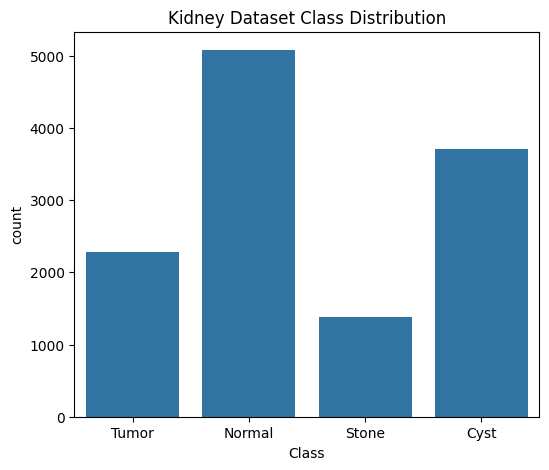

Found 12446 files belonging to 4 classes.
Using 9957 files for training.
Found 12446 files belonging to 4 classes.
Using 2489 files for validation.


In [33]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf


# Read CSV (EDA Only)


csv_path = "/kaggle/input/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone/kidneyData.csv"

df = pd.read_csv(csv_path)

print(df.head())
print(df.shape)
print(df.isnull().sum())

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print(df["Class"].value_counts())

plt.figure(figsize=(6,5))
sns.countplot(data=df, x="Class")
plt.title("Kidney Dataset Class Distribution")
plt.show()


# Dataset Path


dataset_path = "/kaggle/input/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32


# Train Dataset (80%)


train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)


# Test Dataset (20%)


test_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)


# Normalize Images


normalization_layer = tf.keras.layers.Rescaling(1./255)
class_names = ["Cyst", "Normal", "Stone", "Tumor"]

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))

test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))


# Improve Performance


AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)




In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)


# Build CNN Model


model = Sequential([

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        input_shape=(224,224,3)
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu"
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation="relu"
    ),

    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        4,
        activation="softmax"
    )

])


# Compile Model


model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# Model Summary


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if "efficient" in file.lower():
            print(os.path.join(root, file))

/kaggle/input/datasets/midofikho/efficientnetb0-notop-h5/efficientnetb0_notop.h5


In [36]:

# Train Model


history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 28s 77ms/step - accuracy: 0.8687 - loss: 0.3523 - val_accuracy: 0.9980 - val_loss: 0.0136
Epoch 2/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.9871 - loss: 0.0357 - val_accuracy: 0.9980 - val_loss: 0.0082
Epoch 3/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.9937 - loss: 0.0186 - val_accuracy: 0.9988 - val_loss: 0.0028
Epoch 4/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.9937 - loss: 0.0194 - val_accuracy: 1.0000 - val_loss: 6.0283e-04
Epoch 5/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.9950 - loss: 0.0161 - val_accuracy: 1.0000 - val_loss: 2.8272e-04
Epoch 6/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.9955 - loss: 0.0123 - val_accuracy: 1.0000 - val_loss: 3.7994e-04
Epoch 7/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.9969 - loss: 0.0097 - val_accuracy: 1.0000 - val_loss: 2.5235e-04
Epoch 8/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.9945 -

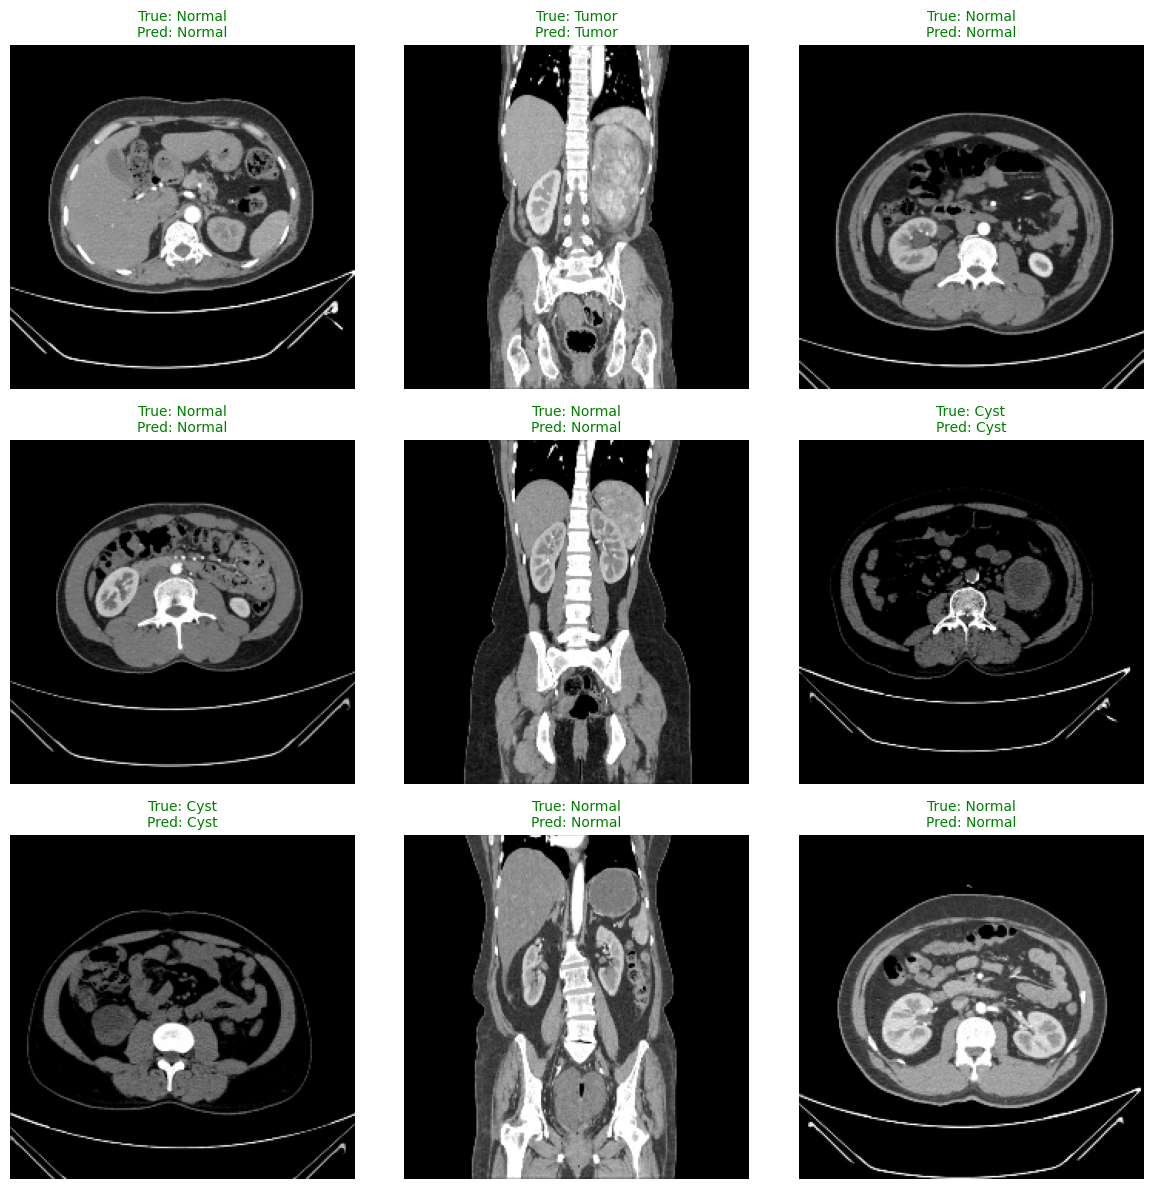

In [37]:
import matplotlib.pyplot as plt
import numpy as np

class_names = ["Cyst", "Normal", "Stone", "Tumor"]

plt.figure(figsize=(12,12))

count = 0

for images, labels in test_dataset:

    predictions = model.predict(images, verbose=0)

    true_labels = np.argmax(labels, axis=1)
    pred_labels = np.argmax(predictions, axis=1)

    for i in range(len(images)):

        plt.subplot(3,3,count+1)

        plt.imshow(images[i])

        color = "green" if true_labels[i] == pred_labels[i] else "red"

        plt.title(
            f"True: {class_names[true_labels[i]]}\nPred: {class_names[pred_labels[i]]}",
            color=color,
            fontsize=10
        )

        plt.axis("off")

        count += 1

        if count == 9:
            break

    if count == 9:
        break

plt.tight_layout()
plt.show()

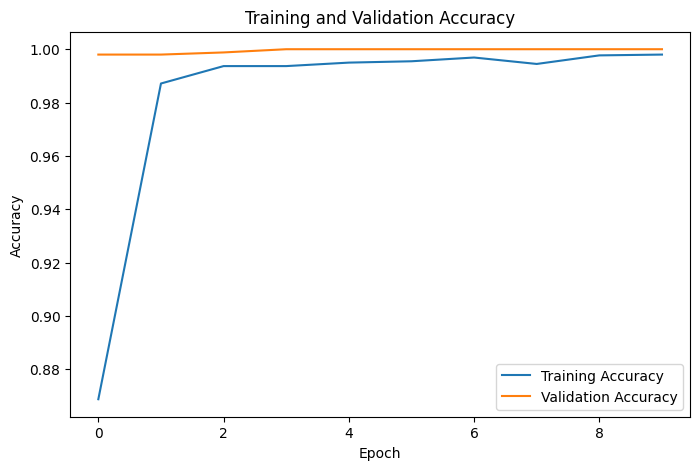

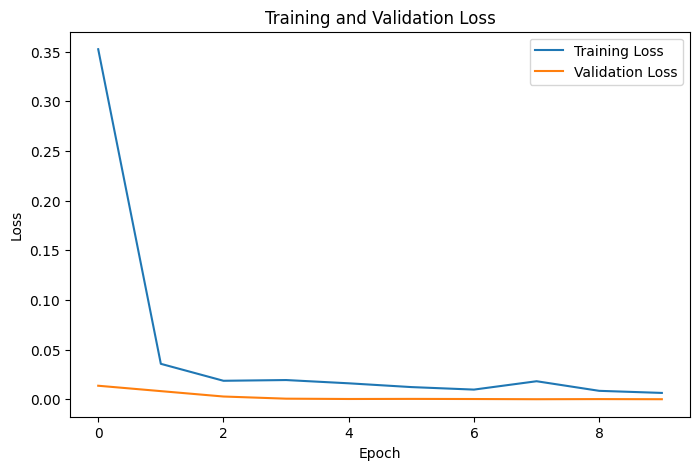

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 5.1545e-05

Test Loss: 0.0001
Test Accuracy: 100.00%
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


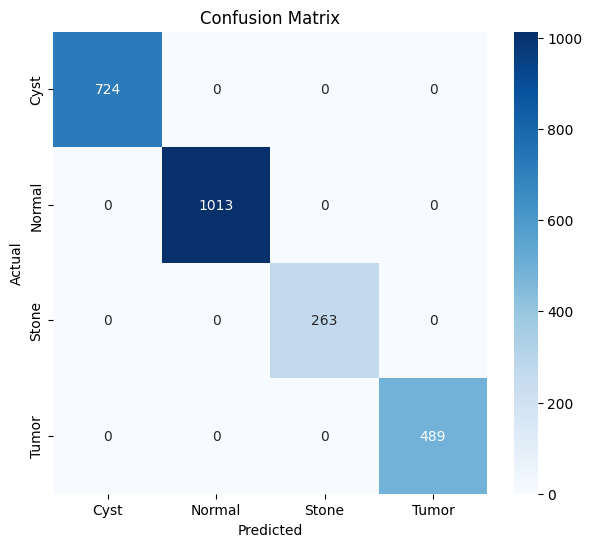

              precision    recall  f1-score   support

        Cyst       1.00      1.00      1.00       724
      Normal       1.00      1.00      1.00      1013
       Stone       1.00      1.00      1.00       263
       Tumor       1.00      1.00      1.00       489

    accuracy                           1.00      2489
   macro avg       1.00      1.00      1.00      2489
weighted avg       1.00      1.00      1.00      2489



In [38]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np




# Plot Accuracy


plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


# Plot Loss


plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


# Evaluate Model


loss, accuracy = model.evaluate(test_dataset)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

# ==========================
# Predictions
# ==========================

y_true = np.concatenate([y for x, y in test_dataset], axis=0)

y_true = np.argmax(y_true, axis=1)

y_pred = model.predict(test_dataset)

y_pred = np.argmax(y_pred, axis=1)
# classes name
class_names = ["Cyst","Normal","Stone","Tumor"]


# Confusion Matrix


cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


# Classification Report


print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

Model Saved Successfully!


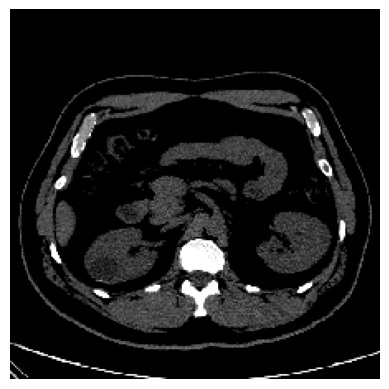

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step
Prediction : Cyst
Confidence : 100.00%


In [39]:


import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Save Model
model.save("kidney_model.keras")
print("Model Saved Successfully!")

# Classes
class_names = ["Cyst", "Normal", "Stone", "Tumor"]


# Enter Image Path


image_path = "/kaggle/input/datasets/midofikho/ccccccc/Cyst- (19).jpg"

# Read Image
img = image.load_img(image_path, target_size=(224,224))

# Show Image
plt.imshow(img)
plt.axis("off")
plt.show()

# Convert to Array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add Batch Dimension
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Prediction :", predicted_class)
print(f"Confidence : {confidence:.2f}%")

In [40]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,508,430 (127.82 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,338,954 (85.22 MB)

In [1]:
loss, accuracy = model.evaluate(test_dataset)

print("Accuracy =", accuracy)

NameError: name 'model' is not defined